<h1 align="center"> Bank Marketing Analysis & Predictions </h1>

---

<h2 align="center">Notebook Information</h2>
<h3 align="center">Revision History</h3>

| Date | Author | Changes |
| :---- | :---- | :---- |
| 2026-07-15 | Charchit (@0xSquawk) | Initial Notebook Setup | 



### Data Source

This project uses the Bank Marketing dataset from the UCI Machine Learning Repository.

**Citation:**
> S. Moro, P. Rita, and P. Cortez. "Bank Marketing," UCI Machine Learning Repository, 2014. [Online]. Available: https://doi.org/10.24432/C5K306.

## Setting up the environment & Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import axes
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features.copy()
y = bank_marketing.data.targets.copy()
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

## Data Preprocessing

In [27]:
# Checking dataset imbalance
print((y.value_counts(normalize=True) * 100).round(2))

y  
no     88.3
yes    11.7
Name: proportion, dtype: float64


The dataset is clearly imbalanced as the proportion of 'yes' in target variable is only 11.69%

In [28]:
# Checking duplicate rows
X.duplicated().sum()

np.int64(0)

In [29]:
# Seperating features based on data types
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

In [30]:
# Checking naming irregularities in unique values for categorical columns
for col in cat_cols:
   print(X[col].value_counts())
   print("")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

default
no     44396
yes      815
Name: count, dtype: int64

housing
yes    25130
no     20081
Name: count, dtype: int64

loan
no     37967
yes     7244
Name: count, dtype: int64

contact
cellular     29285
telephone     2906
Name: count, dtype: int64

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

poutcome
failure    4901
other      1840
success    1511
Name: count, dtype: int64



In the 'job' feature, we need to fix the 'admin.' value to 'admin'

In [31]:
# Fixing the 'admin.' inside 'job' feature
X['job'] = X['job'].replace({'admin.' : 'admin'})

In [32]:
# Checking for null values
print(X.isna().sum())

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64


In [33]:
# Calculating percentage of missing values
missing_percentage_job = X['job'].isna().sum() / X.shape[0] * 100
print(f"Missing 'job' percentage: {missing_percentage_job:.2f}")

missing_percentage_education = X['education'].isna().sum() / X.shape[0] * 100
print(f"Missing 'education' percentage: {missing_percentage_education:.2f}")

missing_percentage_contact = X['contact'].isna().sum() / X.shape[0] * 100
print(f"Missing 'contact' percentage: {missing_percentage_contact:.2f}")

missing_percentage_poutcome = X['poutcome'].isna().sum() / X.shape[0] * 100
print(f"Missing 'poutcome' percentage: {missing_percentage_poutcome:.2f}")

Missing 'job' percentage: 0.64
Missing 'education' percentage: 4.11
Missing 'contact' percentage: 28.80
Missing 'poutcome' percentage: 81.75


Observations:
1. Since 'job' and 'education' features have less than 5% missing values, we have a lot of flexibility here. I am choosing to fill them using 'unknown' however we can also use mode imputation in such scenario. 
2. The 'contact' feature is missing 28.80% data, which is a significant number. However imputing this column with 'cellular' or 'telephone' contacts may introduce a lot of bias hence we will use 'unknown' here as well. 
3. The 'poutcome' feature has 81.75% missing data which is structurally missing as the missingness is completely dependent on the 'previous' feature (which tracks the number of contacts before this campaign) and the 'pdays' feature (days since the last contact), either we can drop this feature or else we can give a new categorization to the missing values.

In [34]:
# Replacing the missing values with 'unknown'

X['job'] = X['job'].fillna('unknown')
X['education'] = X['education'].fillna('unknown')
X['contact'] = X['contact'].fillna('unknown')
X['poutcome'] = X['poutcome'].fillna('unknown')

In [35]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          45211 non-null  object
 2   marital      45211 non-null  object
 3   education    45211 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      45211 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     45211 non-null  object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [36]:
X.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


The dataset documentation mentions that pdays = number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)

I will create a dummy variable as a new feature for '-1' observations as we will be testing a diverse set of algorithms through cross validation, leaving it as '-1' will detroit the performance of linear and distance based models. The original '-1' values in the pdays will be replaced using median imputation from the positive range having rest of the values. 

In [37]:
# Creating a new column for '-1' values in the pdays column
X['never_contacted'] = (X['pdays'] == -1).astype(int)

# Finding the median of the actual contacted days
median_pdays = X.loc[X['pdays'] != -1, 'pdays'].median()
X['pdays'] = X['pdays'].replace({-1: median_pdays})

## Exploratory Data Analysis

### Univariate Analysis

In [38]:
X.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous,never_contacted
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,199.584482,0.580323,0.817367
std,10.618762,3044.765829,8.322476,257.527812,3.098021,50.686537,2.303441,0.386369
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,194.000000,0.000000,1.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,194.000000,0.000000,1.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,194.000000,0.000000,1.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


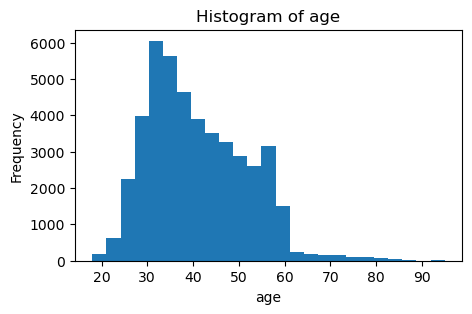

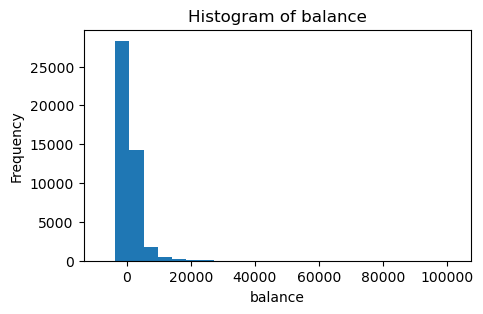

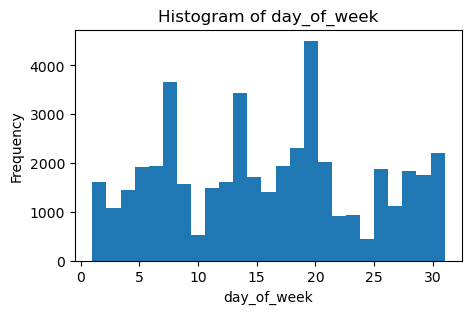

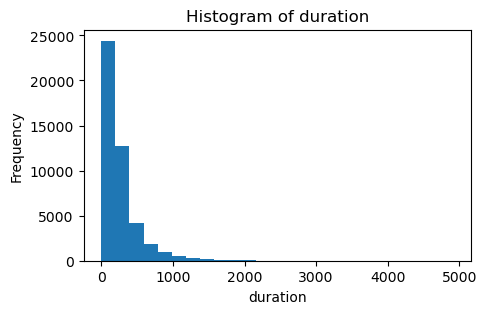

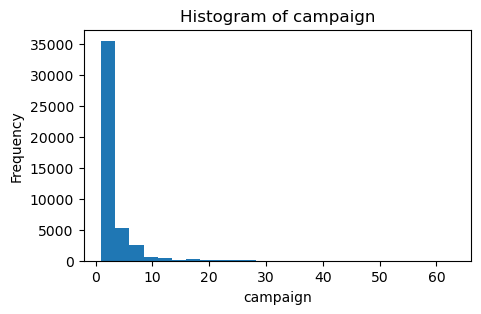

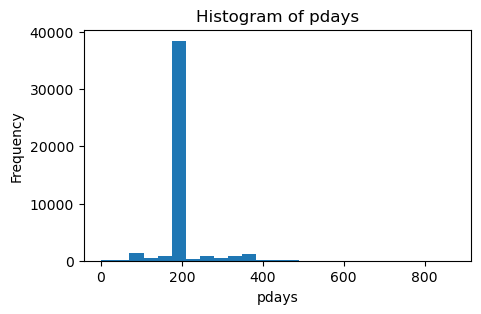

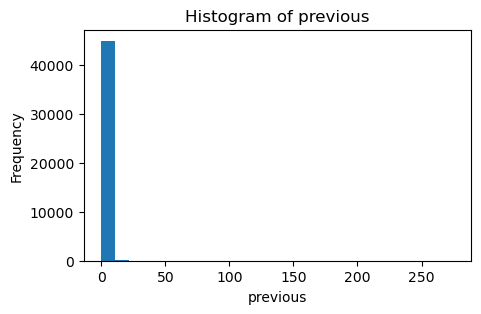

In [ ]:
# Plotting numerical columns to check the frequency and occurence
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(X[col], bins=25)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

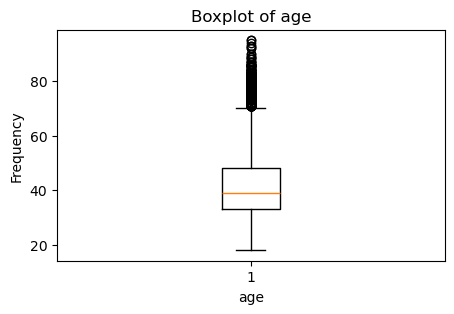

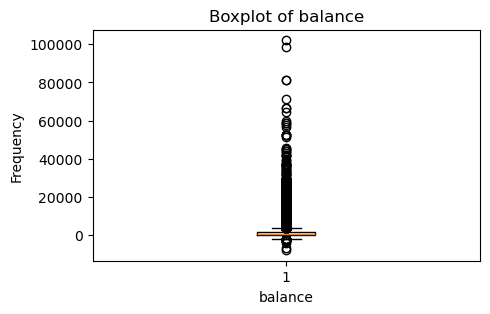

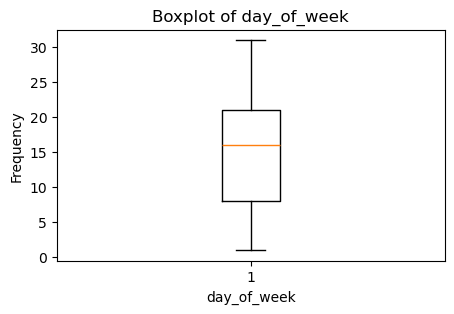

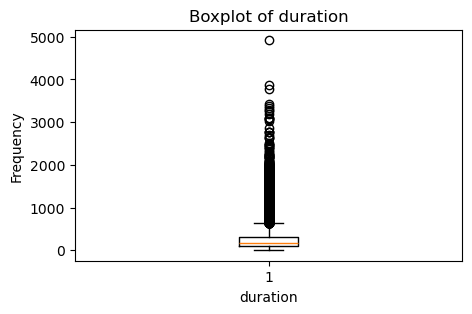

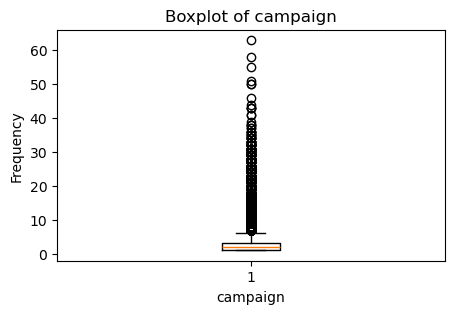

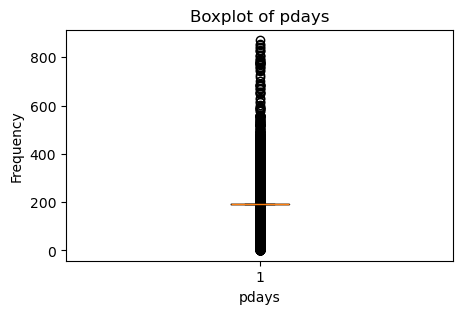

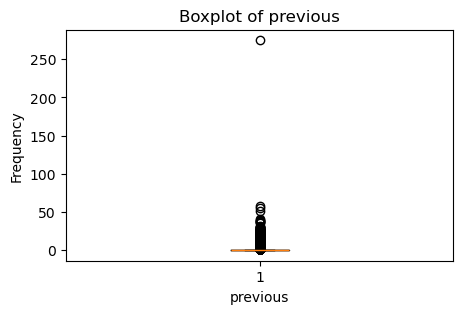

In [55]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(X[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

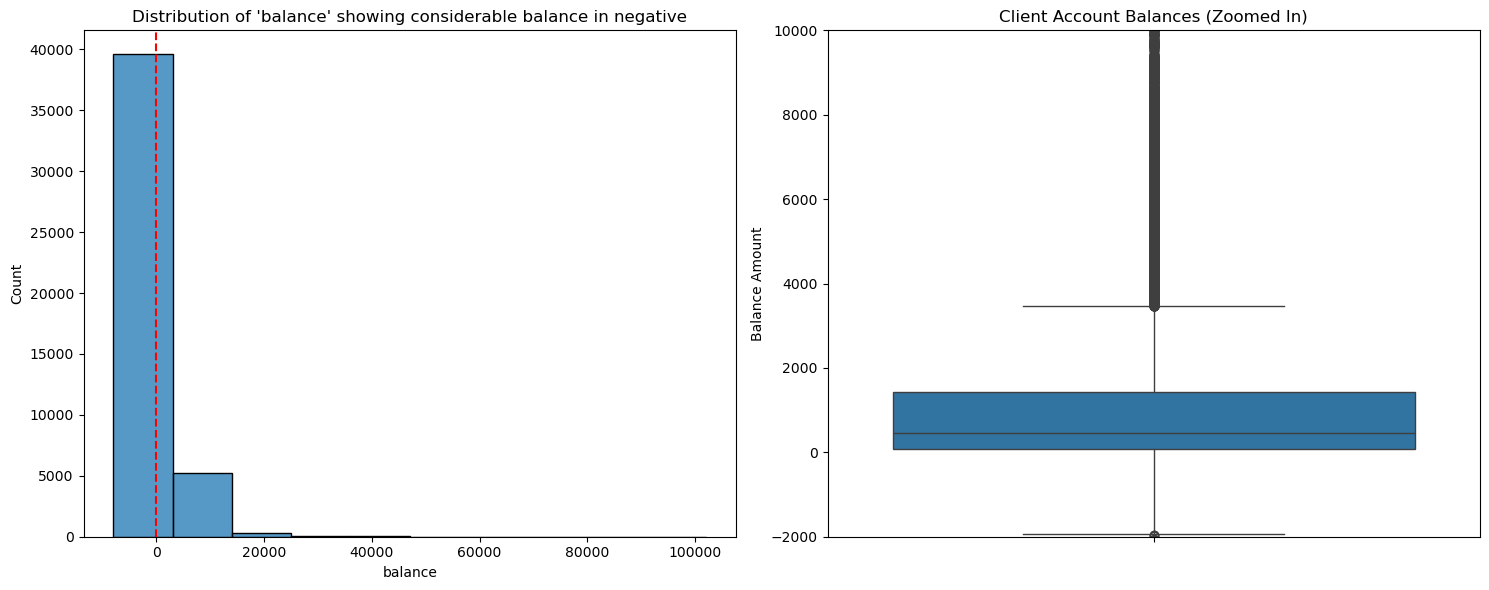

In [ ]:
# Observing the 'balance' feature for negative values
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.histplot(data=X, x='balance', bins=10, ax=axes[0])
axes[0].set_title("Distribution of 'balance' showing considerable balance in negative")
axes[0].axvline(x=0, color='red', linestyle='--') 

sns.boxplot(y=X['balance'], ax=axes[1])
axes[1].set_ylim(-2000, 10000) 
axes[1].set_title("Client Account Balances (Zoomed In)")
axes[1].set_ylabel("Balance Amount")

plt.tight_layout()
plt.show()

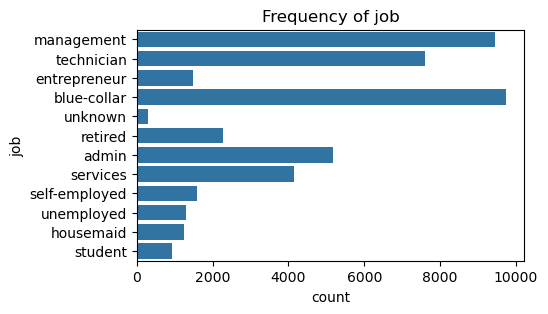

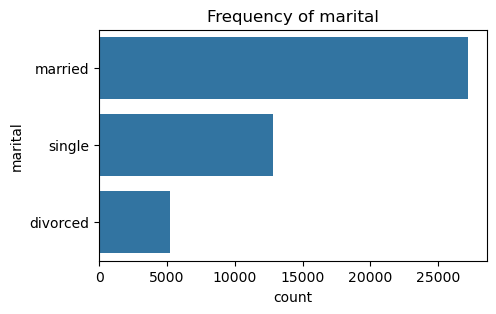

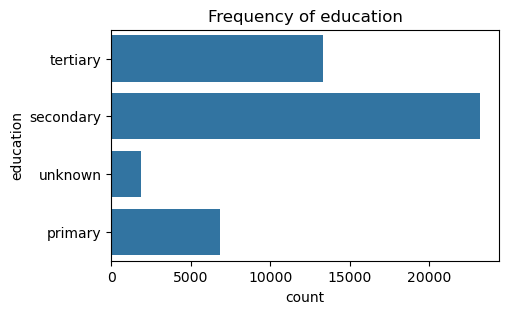

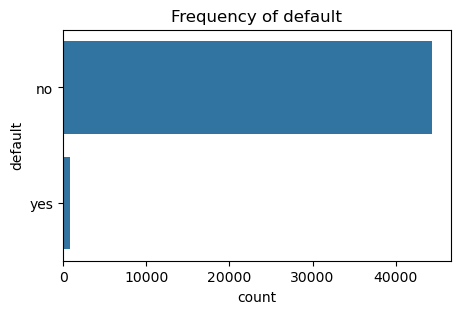

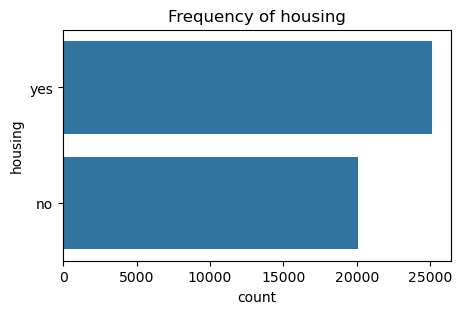

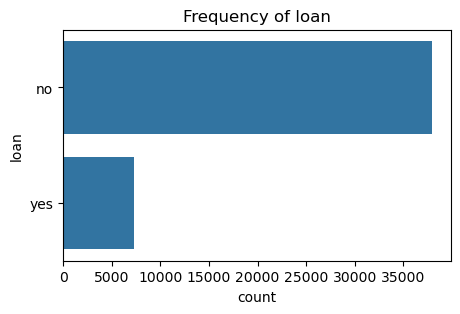

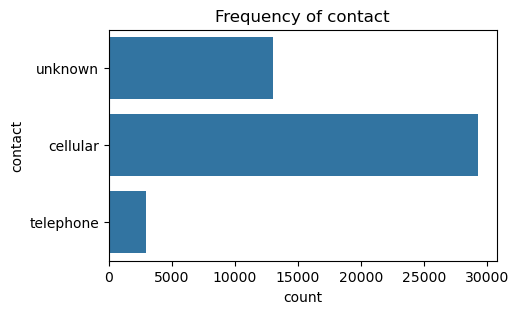

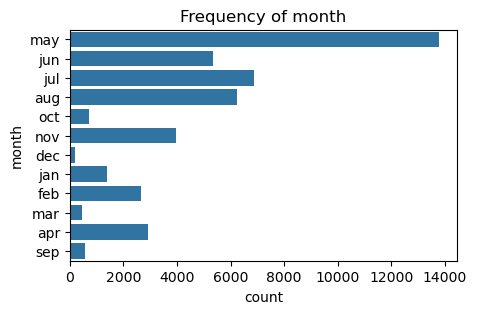

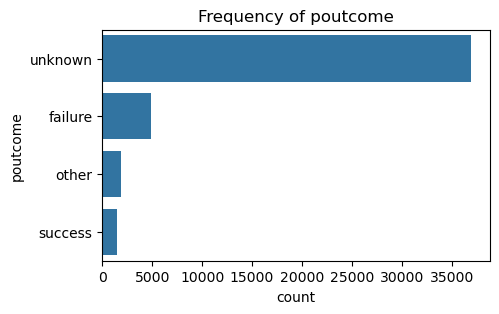

In [61]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=X, y=col) 
    plt.title(f"Frequency of {col}")
    plt.show()

### Bivariate Analysis

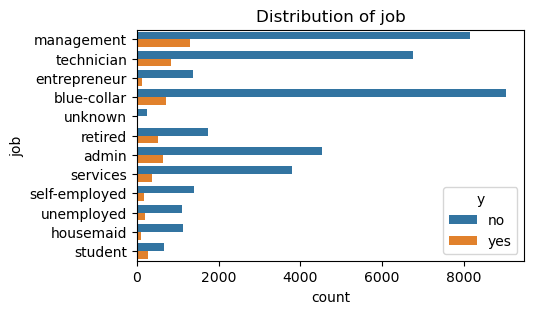

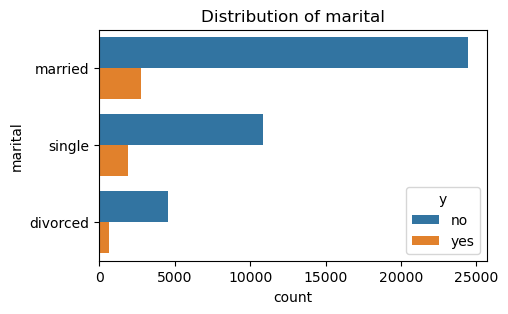

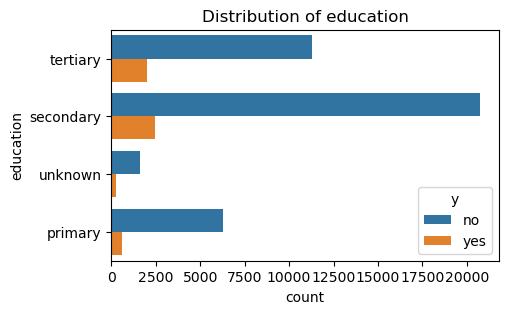

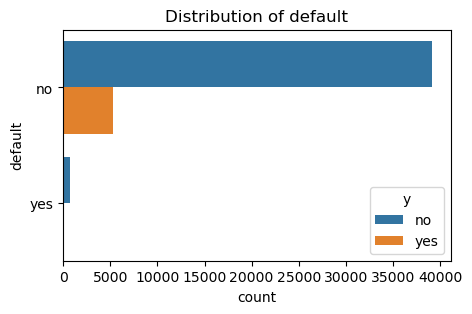

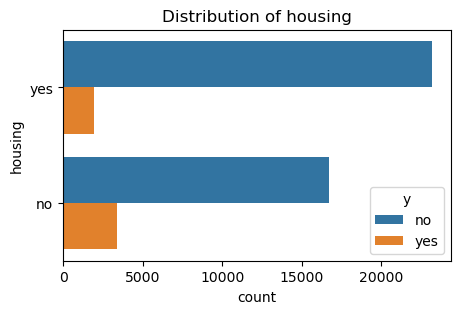

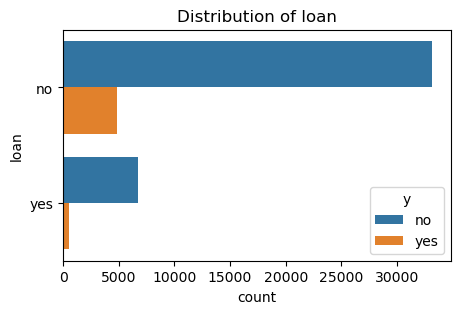

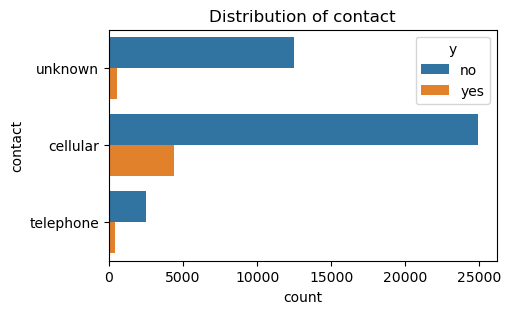

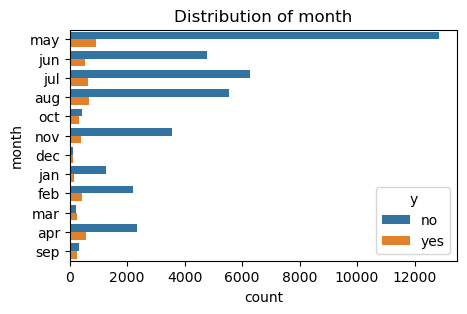

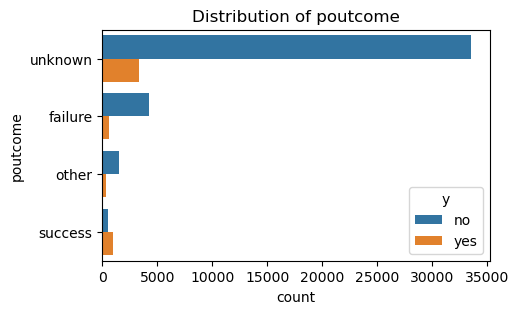

In [74]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=X, y=col, hue=y['y']) 
    plt.title(f"Distribution of {col}")
    plt.show()

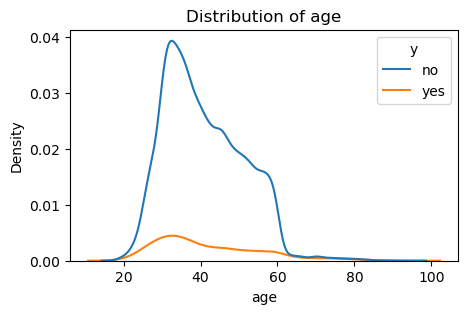

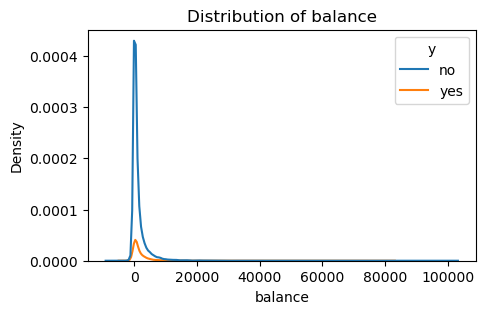

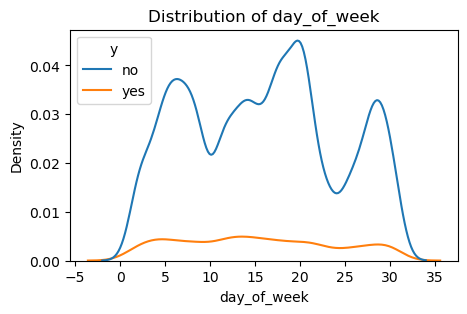

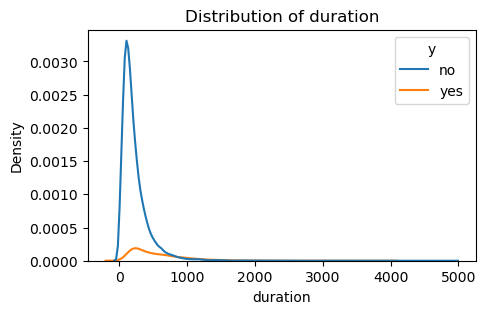

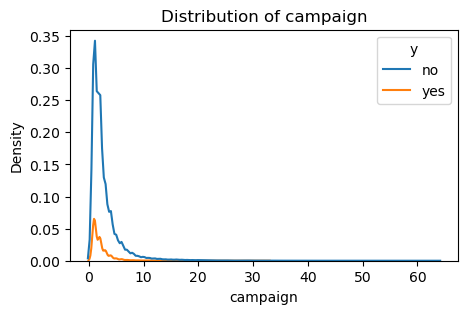

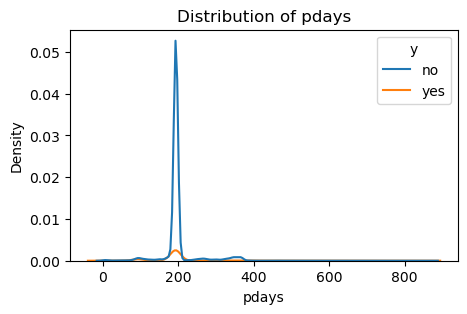

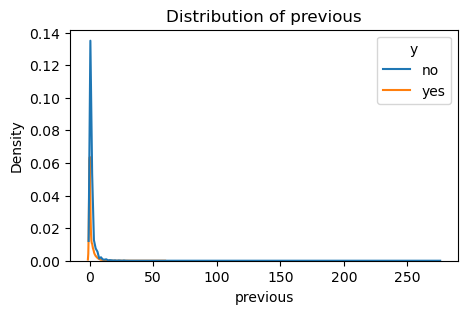

In [72]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(data=X, x=col, hue=y['y']) 
    plt.title(f"Distribution of {col}")
    plt.show()

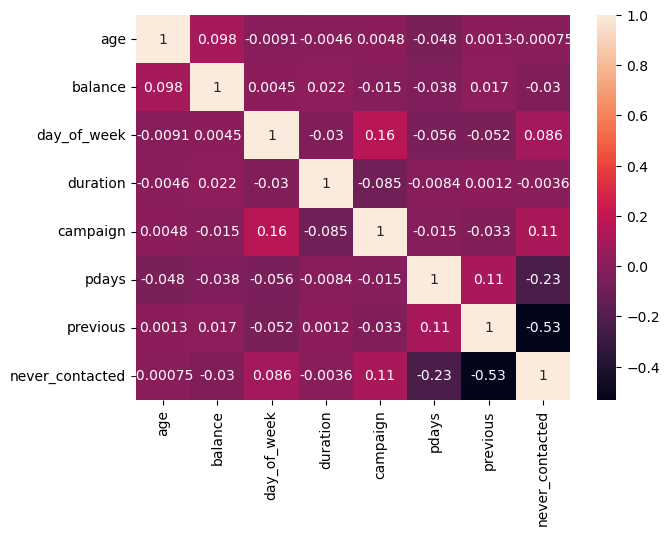

In [84]:
numerical_cor = X.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(numerical_cor, annot=True)
plt.show()

### Chi Suqare Test & Cramér's V

In [85]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,never_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,194,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,194,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,194,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,194,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,194,0,unknown,1


## **---Work in Progress---**